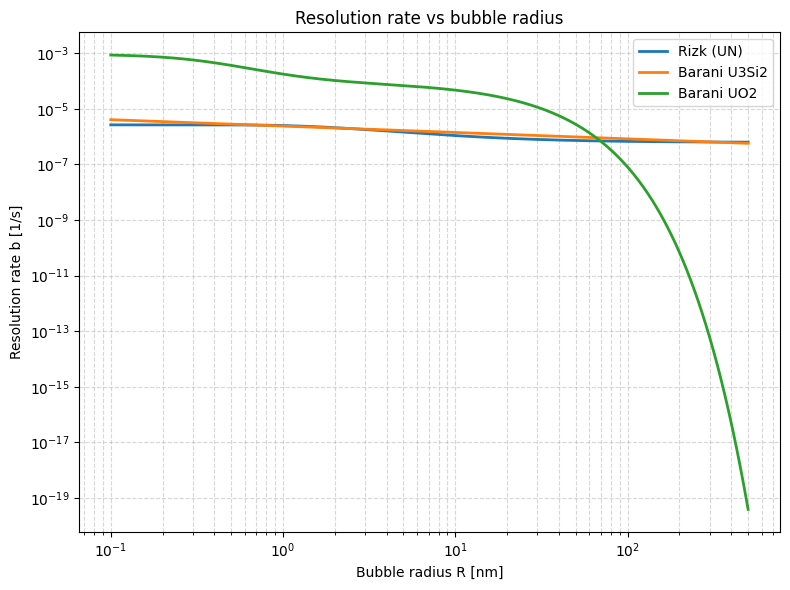


===== Resolution rate values =====

Rizk (UN):
  R_min = 1.000e-01 nm → b = 2.640e-06 s^-1
  R_mid = 7.079e+00 nm → b = 1.247e-06 s^-1
  R_max = 5.012e+02 nm → b = 6.305e-07 s^-1

Barani (U3Si2):
  R_min = 1.000e-01 nm → b = 4.054e-06 s^-1
  R_mid = 7.079e+00 nm → b = 1.525e-06 s^-1
  R_max = 5.012e+02 nm → b = 5.714e-07 s^-1

Barani (UO2):
  R_min = 1.000e-01 nm → b = 8.562e-04 s^-1
  R_mid = 7.079e+00 nm → b = 5.811e-05 s^-1
  R_max = 5.012e+02 nm → b = 3.877e-20 s^-1


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Parametri
# =========================
F = 1e19  # fission rate [m^-3 s^-1]

# Range R: 0.1 nm → 500 nm
R = np.logspace(-10, -6.3, 500)  # in metri (~1e-10 → ~5e-7)

# =========================
# 1. Rizk (UN)
# =========================
b0_rizk = 1e-25 * (2.64 - 2.02 * np.exp(-2.61e-9 / R))
b_rizk = b0_rizk * F

# =========================
# 2. Barani (U3Si2)
# =========================
b0_barani_si = 2.80e-25 * (5e-10 / R)**0.23
b_barani_si = b0_barani_si * F

# =========================
# 3. Barani (UO2)
# =========================
a = 9.49e-24
b0 = 9.18e-23
b1 = 7.07e7
c = 7.982e18
d = 3.71e16

b0_barani_uo2 = (
    a * np.exp(-b1 * R)
    + ((b0 - a) / (1 + c * R**2)) * np.exp(-d * R**2)
)

b_barani_uo2 = b0_barani_uo2 * F

# =========================
# Plot
# =========================
plt.figure(figsize=(8,6))

plt.loglog(R*1e9, b_rizk, label='Rizk (UN)', linewidth=2)
plt.loglog(R*1e9, b_barani_si, label='Barani U3Si2', linewidth=2)
plt.loglog(R*1e9, b_barani_uo2, label='Barani UO2', linewidth=2)

plt.xlabel('Bubble radius R [nm]')
plt.ylabel('Resolution rate b [1/s]')
plt.title('Resolution rate vs bubble radius')

plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# =========================
# Valori caratteristici
# =========================

# R minimo, massimo e medio (geometrico)
R_min = R[0]
R_max = R[-1]
R_mid = np.sqrt(R_min * R_max)  # media logaritmica (più corretta qui)

print("\n===== Resolution rate values =====")

def print_values(name, b_array):
    b_min = b_array[0]
    b_max = b_array[-1]
    
    # trova il valore più vicino a R_mid
    idx_mid = np.argmin(np.abs(R - R_mid))
    b_mid = b_array[idx_mid]
    
    print(f"\n{name}:")
    print(f"  R_min = {R_min*1e9:.3e} nm → b = {b_min:.3e} s^-1")
    print(f"  R_mid = {R_mid*1e9:.3e} nm → b = {b_mid:.3e} s^-1")
    print(f"  R_max = {R_max*1e9:.3e} nm → b = {b_max:.3e} s^-1")

# stampa per i tre modelli
print_values("Rizk (UN)", b_rizk)
print_values("Barani (U3Si2)", b_barani_si)
print_values("Barani (UO2)", b_barani_uo2)

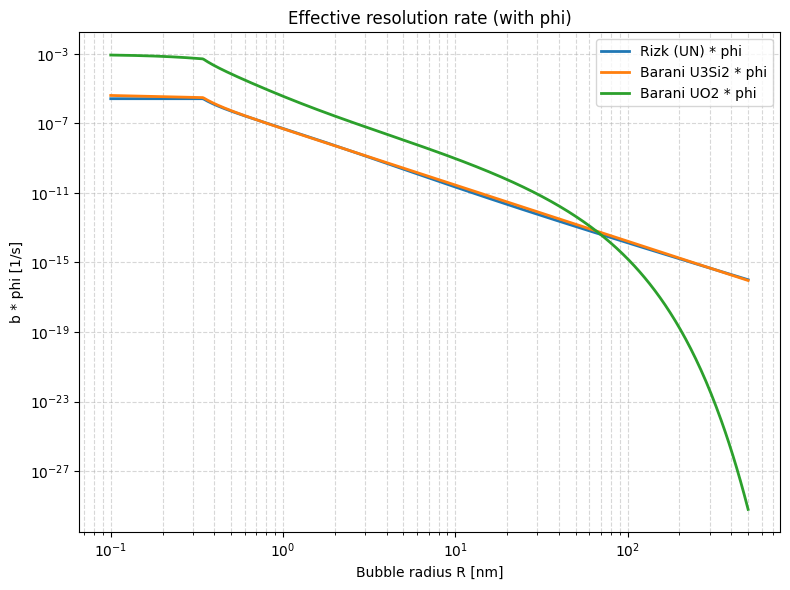


===== Resolution rate * phi =====

Rizk (UN):
  R_min = 1.000e-01 nm → b·phi = 2.640e-06 s^-1
  R_mid = 7.079e+00 nm → b·phi = 7.319e-11 s^-1
  R_max = 5.012e+02 nm → b·phi = 1.016e-16 s^-1

Barani (U3Si2):
  R_min = 1.000e-01 nm → b·phi = 4.054e-06 s^-1
  R_mid = 7.079e+00 nm → b·phi = 8.949e-11 s^-1
  R_max = 5.012e+02 nm → b·phi = 9.210e-17 s^-1

Barani (UO2):
  R_min = 1.000e-01 nm → b·phi = 8.562e-04 s^-1
  R_mid = 7.079e+00 nm → b·phi = 3.410e-09 s^-1
  R_max = 5.012e+02 nm → b·phi = 6.249e-30 s^-1


In [8]:
# =========================
# Phi e m(R)
# =========================

Omega_fg = 8.5e-29  # [m^3]

# numero medio di atomi nella bolla
m = (4/3) * np.pi * R**3 / Omega_fg
m_safe = np.maximum(m, 2.0)

# phi
phi = 1 / (m_safe - 1)

# =========================
# b * phi
# =========================
bphi_rizk = b_rizk * phi
bphi_barani_si = b_barani_si * phi
bphi_barani_uo2 = b_barani_uo2 * phi

plt.figure(figsize=(8,6))

plt.loglog(R*1e9, bphi_rizk, label='Rizk (UN) * phi', linewidth=2)
plt.loglog(R*1e9, bphi_barani_si, label='Barani U3Si2 * phi', linewidth=2)
plt.loglog(R*1e9, bphi_barani_uo2, label='Barani UO2 * phi', linewidth=2)

plt.xlabel('Bubble radius R [nm]')
plt.ylabel('b * phi [1/s]')
plt.title('Effective resolution rate (with phi)')

plt.legend()
plt.grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# =========================
# Valori caratteristici (b * phi)
# =========================

# R minimo, massimo e medio (geometrico)
R_min = R[0]
R_max = R[-1]
R_mid = np.sqrt(R_min * R_max)

print("\n===== Resolution rate * phi =====")

def print_values(name, bphi_array):
    b_min = bphi_array[0]
    b_max = bphi_array[-1]
    
    # indice del valore più vicino a R_mid
    idx_mid = np.argmin(np.abs(R - R_mid))
    b_mid = bphi_array[idx_mid]
    
    print(f"\n{name}:")
    print(f"  R_min = {R_min*1e9:.3e} nm → b·phi = {b_min:.3e} s^-1")
    print(f"  R_mid = {R_mid*1e9:.3e} nm → b·phi = {b_mid:.3e} s^-1")
    print(f"  R_max = {R_max*1e9:.3e} nm → b·phi = {b_max:.3e} s^-1")

# stampa
print_values("Rizk (UN)", bphi_rizk)
print_values("Barani (U3Si2)", bphi_barani_si)
print_values("Barani (UO2)", bphi_barani_uo2)